## Phase 1

In [28]:
import os
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig
from drain3.masking import MaskingInstruction

# File paths
log_file_path = "BGL/BGL_2k.log"
ground_truth_path = "BGL/BGL_2k.log_structured.csv"
output_csv_path = "results/top_templates.csv"

In [29]:
# Load log file lines
with open(log_file_path, "r", encoding="utf-8") as f:
    log_lines = f.readlines()

total_lines = len(log_lines)
print(f"Total lines in BGL log file: {total_lines}")

Total lines in BGL log file: 2000


In [30]:
def extract_log_message(line):
    parts = line.strip().split()
    if len(parts) > 9:
        return " ".join(parts[9:])
    elif len(parts) > 0:
        return parts[-1]
    return ""

# Extract message bodies
preprocessed_messages = [extract_log_message(line) for line in log_lines]


In [31]:
grouth_truth_df = pd.read_csv(ground_truth_path)
print(grouth_truth_df["Level"].value_counts())

Level
INFO       1597
FATAL       347
ERROR        41
WARNING       8
SEVERE        7
Name: count, dtype: int64


In [32]:
config = TemplateMinerConfig()
config.masking_instructions = [
    MaskingInstruction(r'\b0x[a-fA-F0-9]+\b', '*'),
    MaskingInstruction(r'\b[a-zA-Z0-9]+(?:[-:][a-zA-Z0-9]+)+\b', '*'),
    MaskingInstruction(r'\b[a-fA-F0-9]{16,}\b', '*'),
    MaskingInstruction(r'\b\d+\b', '*')
]
config.drain_sim_th = 0.1
config.drain_depth = 12
miner = TemplateMiner(config=config)

# Parse all messages
for msg in preprocessed_messages:
    miner.add_log_message(msg)
    
for cluster in miner.drain.clusters:
    print(f"Template: {cluster.get_template()}")
    print(f"Count: {cluster.size}")
    print("-" * 40)

Template: instruction cache parity error corrected
Count: 42
----------------------------------------
Template: <*> <*> alignment exceptions
Count: 109
----------------------------------------
Template: CE sym <*>, at <*>, mask <*>
Count: 92
----------------------------------------
Template: ciod: failed to read message prefix on control stream (CioStream socket to <*>.<*>.<*>.<*>
Count: 3
----------------------------------------
Template: generating core.<*>
Count: 721
----------------------------------------
Template: force load/store alignment...............<*>
Count: 2
----------------------------------------
Template: ciod: cpu <*> at treeaddr <*> sent unrecognized message <*>
Count: 1
----------------------------------------
Template: ciod: LOGIN <*> failed: No such file or directory
Count: 18
----------------------------------------
Template: <*> ddr errors(s) detected and corrected on rank <*>, symbol <*>, bit <*>
Count: 18
----------------------------------------
Template: dat

In [33]:
# Load ground truth to check templates count
gt_df = pd.read_csv(ground_truth_path)
gt_templates_count = gt_df['EventTemplate'].nunique()
print(f"Ground Truth unique templates count: {gt_templates_count}")
thresholds = [0.1, 0.3, 0.5, 0.7]
results_tuning = {}

for th in thresholds:
    config = TemplateMinerConfig()
    config.masking_instructions = [
        MaskingInstruction(r'\b0x[a-fA-F0-9]+\b', '*'),
        MaskingInstruction(r'\b[a-zA-Z0-9]+(?:[-:][a-zA-Z0-9]+)+\b', '*'),
        MaskingInstruction(r'\b[a-fA-F0-9]{16,}\b', '*'),
        MaskingInstruction(r'\b[a-fA-F0-9]{8,15}\b', '*'),
        MaskingInstruction(r'\b\d+\b', '*')
    ]
    config.drain_sim_th = th
    config.drain_depth = 12
    miner = TemplateMiner(config=config)
    
    # Parse all messages
    for msg in preprocessed_messages:
        miner.add_log_message(msg)
        
    num_templates = len(miner.drain.clusters)
    results_tuning[th] = num_templates
    print(f"Similarity Threshold: {th} -> Generated {num_templates} templates")

# Select the threshold closest to the ground truth count
best_th = min(results_tuning.keys(), key=lambda th: abs(results_tuning[th] - gt_templates_count))
print(f"\nBest similarity threshold: {best_th} (produces {results_tuning[best_th]} templates, closest to {gt_templates_count})")

Ground Truth unique templates count: 120
Similarity Threshold: 0.1 -> Generated 120 templates
Similarity Threshold: 0.3 -> Generated 120 templates
Similarity Threshold: 0.5 -> Generated 120 templates
Similarity Threshold: 0.7 -> Generated 466 templates

Best similarity threshold: 0.1 (produces 120 templates, closest to 120)


## Phase 2: Anomaly Detection on Logs

In [34]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

df = pd.read_csv("BGL/BGL_2k.log_structured.csv")
df['Datetime'] = pd.to_datetime(df['Timestamp'], unit='s')
df = df.set_index('Datetime')

template_counts = df.groupby([pd.Grouper(freq='5min'), 'EventTemplate']).size().unstack(fill_value=0)
print(f"Template count time series shape: {template_counts.shape}")

iso_forest = IsolationForest(contamination=0.1, random_state=42, n_estimators=300)
template_counts['anomaly_pred'] = iso_forest.fit_predict(template_counts.values)

anomalous_windows = template_counts[template_counts['anomaly_pred'] == -1]
print(f"Detected {len(anomalous_windows)} anomalous windows out of {len(template_counts)} total log-active windows.")

Template count time series shape: (831, 120)
Detected 81 anomalous windows out of 831 total log-active windows.


In [35]:
# 4. Detect: Which templates spiked abnormally?
if len(anomalous_windows) > 0:
    normal_windows = template_counts[template_counts['anomaly_pred'] == 1].drop(columns=['anomaly_pred'])
    mean_normal = normal_windows.mean()
    std_normal = normal_windows.std()
    
    print("Templates with abnormal spikes in the detected windows:")
    for idx, row in anomalous_windows.drop(columns=['anomaly_pred']).iterrows():
        # Spike definition: count > mean + 3*std
        spikes = row[row > mean_normal + 3 * std_normal]
        if not spikes.empty:
            print(f"- Window {idx}: Spikes in templates -> {spikes.index.tolist()}")

Templates with abnormal spikes in the detected windows:
- Window 2005-06-14 00:50:00: Spikes in templates -> ['instruction address: <*>']
- Window 2005-06-14 16:05:00: Spikes in templates -> ['data storage interrupt']
- Window 2005-06-14 16:10:00: Spikes in templates -> ['data storage interrupt', 'instruction address: <*>']
- Window 2005-06-14 16:15:00: Spikes in templates -> ['instruction address: <*>']
- Window 2005-06-14 16:35:00: Spikes in templates -> ['data address: <*>', 'instruction address: <*>']
- Window 2005-06-14 16:40:00: Spikes in templates -> ['machine check: i-fetch......................<*>', 'program interrupt: illegal instruction......<*>']
- Window 2005-06-14 16:50:00: Spikes in templates -> ['data storage interrupt', 'instruction address: <*>']
- Window 2005-06-14 16:55:00: Spikes in templates -> ['data address: <*>', 'data storage interrupt', 'machine check: i-fetch......................<*>']
- Window 2005-06-14 17:15:00: Spikes in templates -> ['data address: <*>'

In [36]:
# 5. Evaluate log-based anomaly detection (Using BGL labels)
# BGL label: '-' is normal, anything else is anomaly
df['is_anomaly'] = (df['Label'] != '-').astype(int)

# Aggregate true labels by 1-min windows (window with any anomaly log -> anomaly window)
window_labels = df.groupby(pd.Grouper(freq='5min'))['is_anomaly'].max()

# Merge true label and predict label
eval_df = pd.DataFrame({
    'true_label': window_labels,
    'pred_label': (template_counts['anomaly_pred'] == -1).astype(int)
}).dropna()

print("Evaluation on Window-level Anomaly Detection:")
print(classification_report(eval_df['true_label'], eval_df['pred_label']))

Evaluation on Window-level Anomaly Detection:
              precision    recall  f1-score   support

         0.0       0.90      0.91      0.91       736
         1.0       0.22      0.19      0.20        95

    accuracy                           0.83       831
   macro avg       0.56      0.55      0.56       831
weighted avg       0.82      0.83      0.83       831



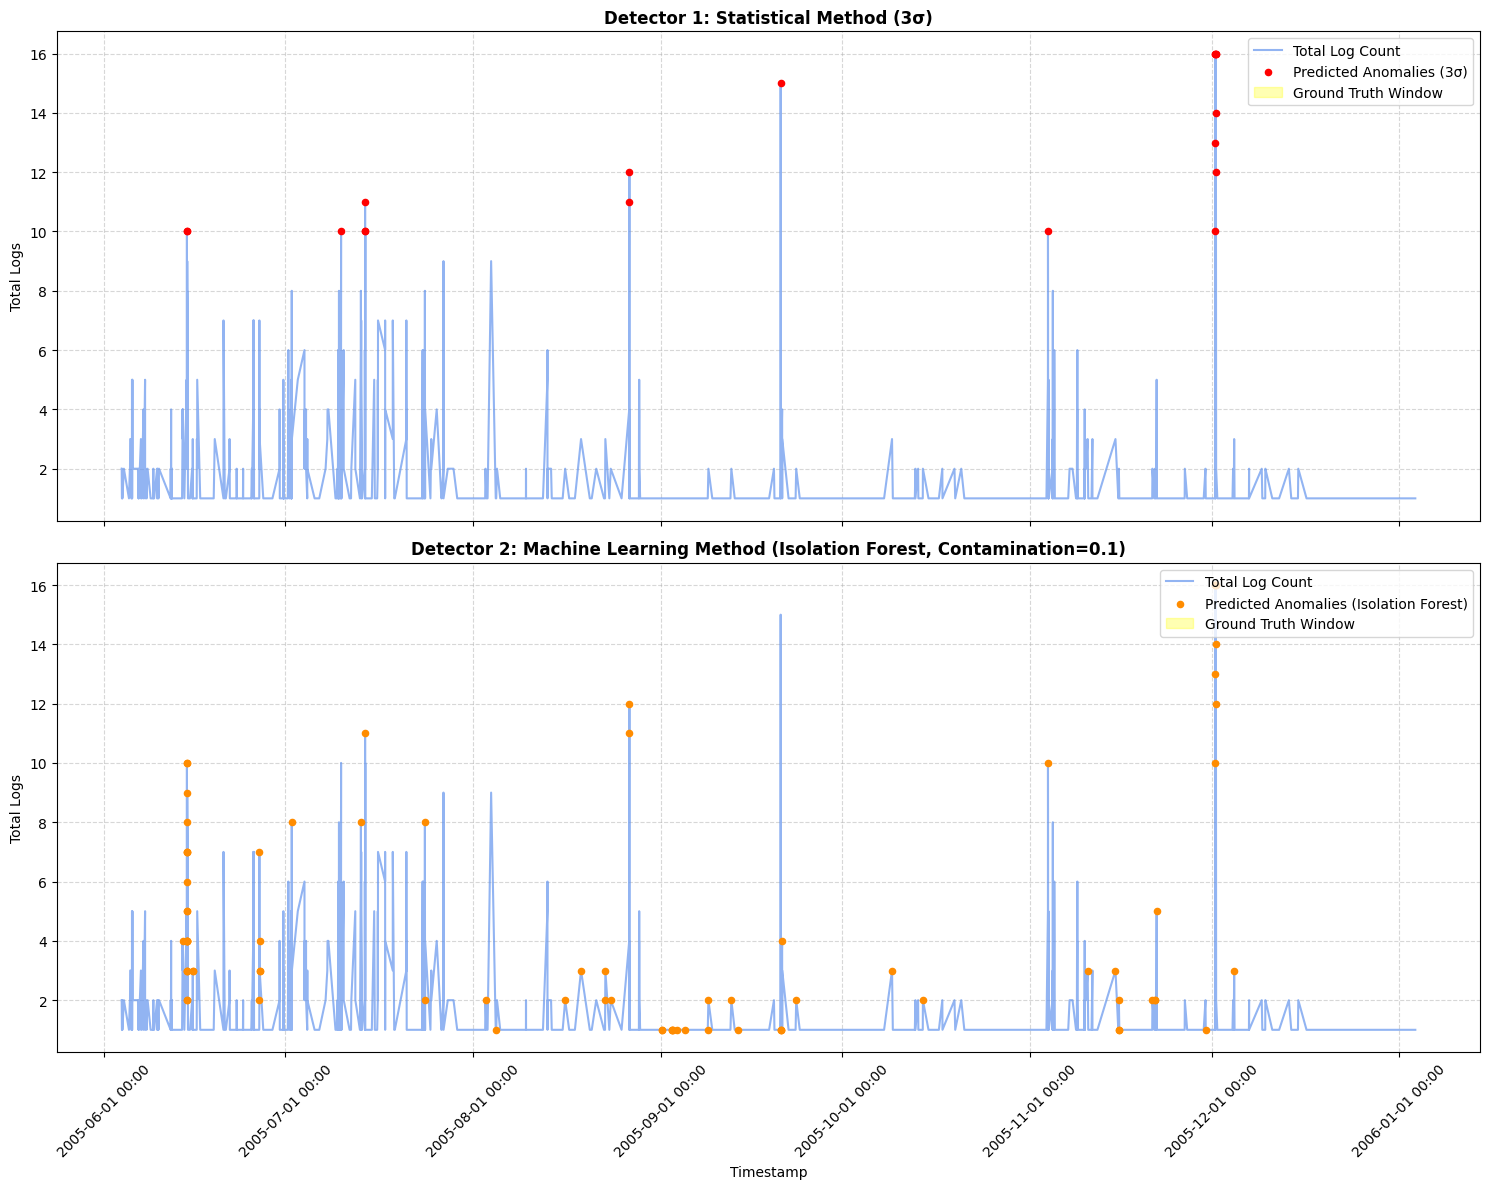

In [37]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

# Calculate total logs in each window for the baseline chart (instead of temperature)
total_counts = template_counts.drop(columns=['anomaly_pred'], errors='ignore').sum(axis=1)

mean_count = total_counts.mean()
std_count = total_counts.std()
threshold = mean_count + 3 * std_count
pred_3sigma = total_counts > threshold

pred_iforest = template_counts['anomaly_pred'] == -1

fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

def plot_ground_truth(ax, index, true_labels):
    # Draw yellow highlights for Ground Truth Anomaly regions
    for time in index[true_labels == 1]:
        ax.axvspan(time - pd.Timedelta(seconds=30), time + pd.Timedelta(seconds=30), 
                   color='yellow', alpha=0.3, lw=0)
    return mpatches.Patch(color='yellow', alpha=0.3, label='Ground Truth Window')

# --- Panel 1: 3-Sigma ---
ax1 = axes[0]
line1, = ax1.plot(total_counts.index, total_counts.values, label='Total Log Count', color='cornflowerblue', alpha=0.7)
scatter1 = ax1.scatter(total_counts.index[pred_3sigma], total_counts.values[pred_3sigma], color='red', label='Predicted Anomalies (3σ)', zorder=5, s=20)
gt_patch1 = plot_ground_truth(ax1, eval_df.index, eval_df['true_label'])
ax1.set_title('Detector 1: Statistical Method (3σ)', fontweight='bold')
ax1.set_ylabel('Total Logs')
ax1.legend(handles=[line1, scatter1, gt_patch1], loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Panel 2: Isolation Forest ---
ax2 = axes[1]
line2, = ax2.plot(total_counts.index, total_counts.values, label='Total Log Count', color='cornflowerblue', alpha=0.7)
scatter2 = ax2.scatter(total_counts.index[pred_iforest], total_counts.values[pred_iforest], color='darkorange', label='Predicted Anomalies (Isolation Forest)', zorder=5, s=20)
gt_patch2 = plot_ground_truth(ax2, eval_df.index, eval_df['true_label'])
ax2.set_title('Detector 2: Machine Learning Method (Isolation Forest, Contamination=0.1)', fontweight='bold')
ax2.set_ylabel('Total Logs')
ax2.set_xlabel('Timestamp')
ax2.legend(handles=[line2, scatter2, gt_patch2], loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.5)

# Format x-axis
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Phase 3: Embedding + Cross-signal
- TF-IDF on templates -> calculate similarity matrix -> find template clusters
- Inject 1 dòng log "lạ" -> Drain3 tạo new template -> detect

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the list of templates learned by Drain3 from Phase 1
templates = [cluster.get_template() for cluster in miner.drain.clusters]
print(f"Total existing templates: {len(templates)}")

# 2. Calculate TF-IDF on templates
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(templates)

# 3. Calculate Similarity Matrix
sim_matrix = cosine_similarity(tfidf_matrix)

# 4. Find Template Clusters using Agglomerative Clustering
n_clusters = 10
clustering = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
cluster_labels = clustering.fit_predict(tfidf_matrix.toarray())

# Show a few representative templates in each cluster
print("\n--- Template Clusters ---")
for i in range(n_clusters):
    print(f"\nCluster {i}:")
    cluster_templates = [templates[j] for j in range(len(templates)) if cluster_labels[j] == i]
    for t in cluster_templates[:3]: # print max 3 templates per cluster for illustration
        print(f"  - {t}")
    print(f"  ... (total {len(cluster_templates)} templates)")

Total existing templates: 466

--- Template Clusters ---

Cluster 0:
  - instruction cache parity error corrected
  - CE sym <*>, at <*>, mask <*>
  - ciod: failed to read message prefix on control stream (CioStream socket to <*>.<*>.<*>.<*>
  ... (total 74 templates)

Cluster 1:
  - force load/store alignment...............<*>
  - data TLB error interrupt
  - data storage interrupt
  ... (total 13 templates)

Cluster 2:
  - <*> ddr errors(s) detected and corrected on rank <*>, symbol <*>, bit <*>
  - total of <*> ddr error(s) detected and corrected
  - <*> torus receiver z+ input pipe error(s) (dcr <*>) detected and corrected
  ... (total 12 templates)

Cluster 3:
  - data address: <*>
  - data address: <*>
  - data address: <*>
  ... (total 10 templates)

Cluster 4:
  - critical input interrupt enable...<*>
  - suppressing further interrupts of same type
  - critical input interrupt (unit=<*> bit=<*>): warning for torus y+ wire
  ... (total 7 templates)

Cluster 5:
  - <*> <*> alignm

In [39]:
# 5. Inject 1 weird log to test Drain3's detection capability
num_clusters_before = len(miner.drain.clusters)

# Create a log line with unseen content
fake_log = "2026-06-02 15:30:00 FATAL ALIEN_INVASION system compromised by UFO signal on port 1337"

# Process through Drain3
result = miner.add_log_message(fake_log)
num_clusters_after = len(miner.drain.clusters)

print(f"Templates before injection: {num_clusters_before}")
print(f"Templates after injection:  {num_clusters_after}")

# Evaluate the results
if result['change_type'] == 'cluster_created':
    print(f"\n[DETECTED] Warning: A completely NEW template just appeared!")
    print(f"-> Original log: {fake_log}")
    print(f"-> Newly created template: {result['template_mined']}")
    print(f"-> Cluster ID: {result['cluster_id']}")
else:
    print("\nLog matched with old template (No new pattern detected).")

Templates before injection: 466
Templates after injection:  467

[DETECTED] Warning: A completely NEW template just appeared!
-> Original log: 2026-06-02 15:30:00 FATAL ALIEN_INVASION system compromised by UFO signal on port 1337
-> Newly created template: <*> <*> FATAL ALIEN_INVASION system compromised by UFO signal on port <*>
-> Cluster ID: 467


In [40]:
import os
import pandas as pd

# Sort clusters by size descending to get top-10
sorted_clusters = sorted(miner.drain.clusters, key=lambda it: it.size, reverse=True)
top_10_clusters = sorted_clusters[:10]

# Prepare data for DataFrame
export_data = []
for cluster in top_10_clusters:
    export_data.append({
        'template_id': cluster.cluster_id,
        'template': cluster.get_template(),
        'count': cluster.size
    })

df_top10 = pd.DataFrame(export_data)

# Ensure results directory exists
os.makedirs('results', exist_ok=True)

# Export to CSV
export_path = 'results/top_templates.csv'
df_top10.to_csv(export_path, index=False)

print(f"Successfully exported top-10 templates to {export_path}")
df_top10.head(10)

Successfully exported top-10 templates to results/top_templates.csv


,template_id,template,count
0,7,generating core.<*>,721
1,174,<*> floating point alignment exceptions,121
2,5,"CE sym <*>, at <*>, mask <*>",92
3,453,<*> total interrupts. <*> critical input inter...,71
4,12,data TLB error interrupt,60
5,452,<*> microseconds spent in the rbs signal handl...,51
6,1,instruction cache parity error corrected,42
7,179,idoproxydb hit ASSERT condition: ASSERT expres...,35
8,14,data storage interrupt,30
9,189,ciod: generated <*> core files for program <*>,30
